<a href="https://colab.research.google.com/github/Hem1144/ml-codes/blob/regression/logical_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Python Spark SQL basic example") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# read data from ml folder
df = spark.read.csv("/content/drive/MyDrive/ml/titanic_synthetic_data.csv", header=True, inferSchema=True)

In [ ]:
df.columns

['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Sex',
 'Survived',
 'Embarked_Q',
 'Embarked_S']

In [ ]:
# Check for Missing Values
from pyspark.sql.functions import isnan, when, count, col
df.select([count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in df.columns]).show()

+------+---+-----+-----+----+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+----+---+--------+----------+----------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|
+------+---+-----+-----+----+---+--------+----------+----------+



In [107]:
# Impute Missing Values (if any)
from pyspark.ml.feature import Imputer

imputer = Imputer(
    inputCols=["Age", "Fare"],
    outputCols=["Age", "Fare"]
)
df = imputer.fit(df).transform(df)


In [112]:
# Dimensionality Reduction with PCA
from pyspark.ml.feature import PCA

pca = PCA(k=5, inputCol="scaled_features", outputCol="pca_features")  # keep top 5 components
df = pca.fit(df).transform(df)

In [113]:
# Train-Test Split
train, test = df.randomSplit([0.8, 0.2], seed=42)

In [114]:
# Handle Class Imbalance
dataset_size = float(train.count())
num_pos = train.filter(col("Survived") == 1).count()
num_neg = dataset_size - num_pos
balancing_ratio = num_neg / dataset_size

train = train.withColumn(
    "classWeight",
    when(col("Survived") == 1, balancing_ratio).otherwise(1 - balancing_ratio)
)

In [115]:
# Train Logistic Regression
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(labelCol="Survived", featuresCol="pca_features", weightCol="classWeight")
model = lr.fit(train)

In [116]:
# Predict and Evaluate
predictions = model.transform(test)
predictions.select("Survived", "prediction", "probability").show(10)

+--------+----------+--------------------+
|Survived|prediction|         probability|
+--------+----------+--------------------+
|       1|       0.0|[0.50038206563963...|
|       0|       0.0|[0.50163817977876...|
|       1|       0.0|[0.50038589159057...|
|       1|       0.0|[0.50039575357142...|
|       1|       0.0|[0.50119626962828...|
|       0|       0.0|[0.50063481857892...|
|       1|       0.0|[0.50110055562368...|
|       1|       0.0|[0.50110980079959...|
|       0|       0.0|[0.50021830729726...|
|       1|       0.0|[0.50055351837544...|
+--------+----------+--------------------+
only showing top 10 rows



In [117]:
# Evaluate ROC AUC
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(labelCol="Survived", rawPredictionCol="rawPrediction")
auroc = evaluator.evaluate(predictions, {evaluator.metricName: "areaUnderROC"})
print(f"Area under ROC: {auroc:.4f}")

Area under ROC: 0.5023


In [118]:
# Confusion Matrix and F1 Score
pr = predictions.select("Survived", "prediction").toPandas()

TP = len(pr[(pr["Survived"] == 1) & (pr["prediction"] == 1)])
TN = len(pr[(pr["Survived"] == 0) & (pr["prediction"] == 0)])
FP = len(pr[(pr["Survived"] == 0) & (pr["prediction"] == 1)])
FN = len(pr[(pr["Survived"] == 1) & (pr["prediction"] == 0)])

precision = TP / (TP + FP) if (TP + FP) else 0
recall = TP / (TP + FN) if (TP + FN) else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Precision: 0.5035
Recall:    0.5012
F1-score:  0.5023


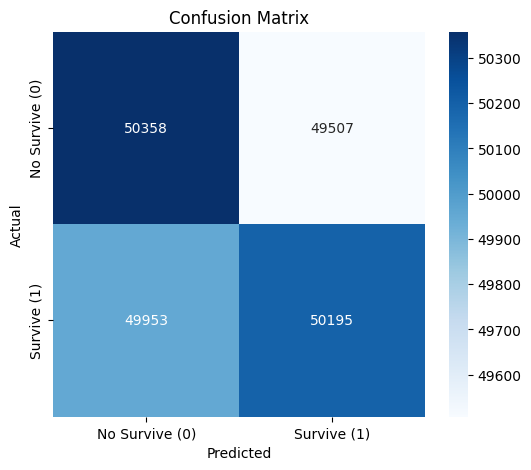

In [119]:
# Confusion Matrix Plot
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrix = np.array([[TN, FP], [FN, TP]])
labels = ["No Survive (0)", "Survive (1)"]

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()